1. Inside Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("busson20.csv")
print(df.columns)  

Index(['TimeBlock', 'AveragePackets', 'AveragePacketsperDevice',
       'AverageConnections', 'AverageConnectionsperDevice',
       'AverageThroughputperDevice', 'MaxThroughputperDevice',
       'ActiveDevicesIP', 'ConnectedDevicesMAC', 'AveragePacketSize',
       'ActiveConnections', 'RatioTIME_WAIT/ESTABLISHED', 'MaxTCPConnections',
       'MaxUDPConnections', 'TimeSinceLastTCPConnection',
       'TimeSinceLastUDPConnection', 'AverageTCPSessionDuration',
       'AverageUDPSessionDuration', 'TimeSinceLastPacket',
       'DeviceScreenState'],
      dtype='object')


In [2]:
pd.DataFrame(df.columns, columns=["Column name"])

,Column name
0,TimeBlock
1,AveragePackets
2,AveragePacketsperDevice
3,AverageConnections
4,AverageConnectionsperDevice
5,AverageThroughputperDevice
6,MaxThroughputperDevice
7,ActiveDevicesIP
8,ConnectedDevicesMAC
9,AveragePacketSize


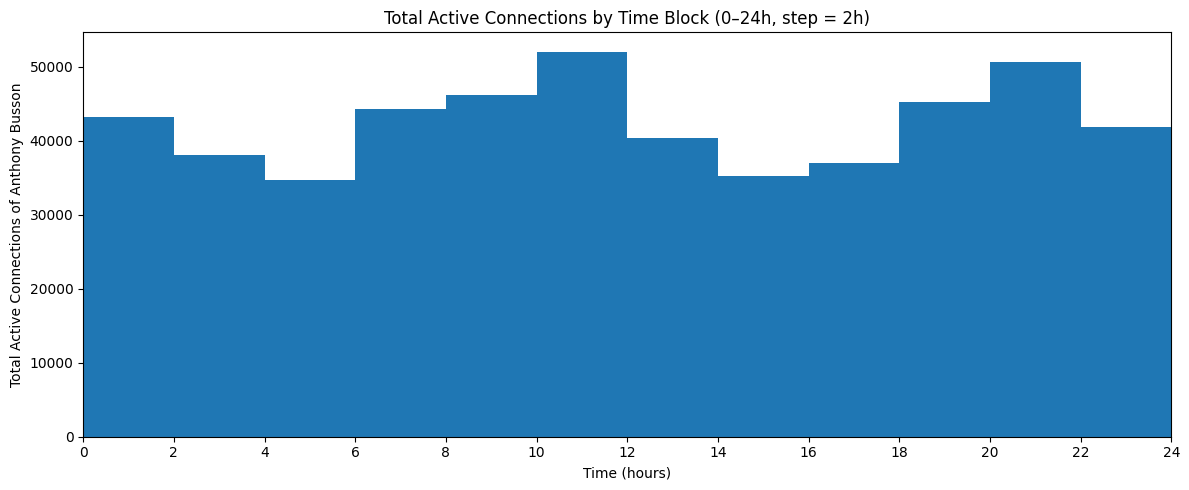

In [3]:
# ===== 1. Data normalization =====
df["ActiveConnections"] = df["ActiveConnections"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Total ActiveConnections per TimeBlock (1 → 12) =====
result = (
    df
    .groupby("TimeBlock")["ActiveConnections"]
    .sum()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_active_connections")
)

# ===== 3. Time block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))
plt.bar(
    x=result["x_left"],
    height=result["total_active_connections"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Total Active Connections of Anthony Busson")
plt.title("Total Active Connections by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()

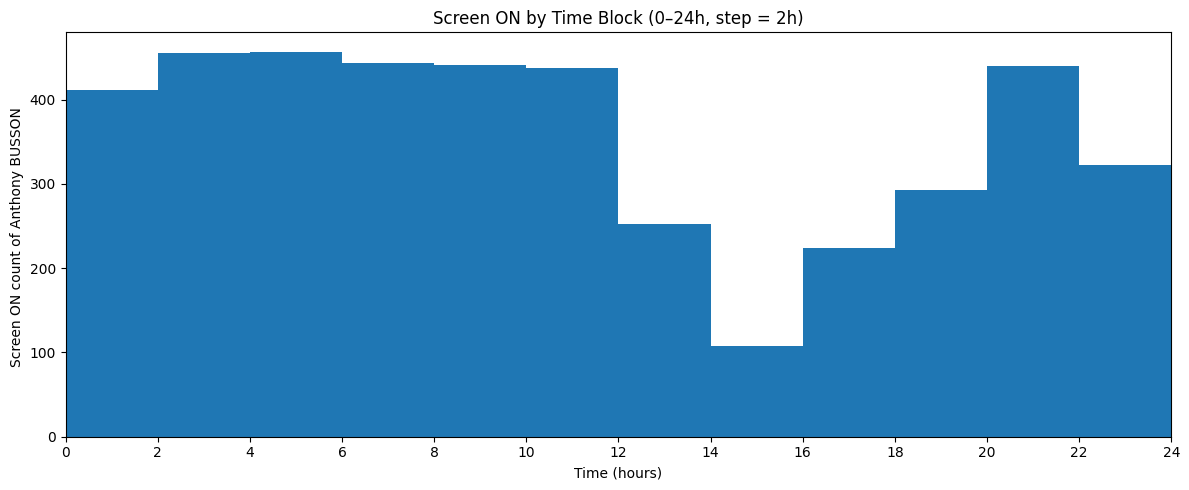

In [4]:
# ===== 1. Data normalization =====
df["DeviceScreenState"] = df["DeviceScreenState"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Create complete Time Blocks 1 → 12 =====
result = (
    df[df["DeviceScreenState"] == 1]
    .groupby("TimeBlock")
    .size()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_rows")
)

# ===== 3. Time Block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))

plt.bar(
    x=result["x_left"],
    height=result["total_rows"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 (DO NOT label 0–2) =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Screen ON count of Anthony BUSSON ")
plt.title("Screen ON by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()

In [5]:
df = pd.read_csv("Ryadh20.csv")
print(df.columns) 

Index(['TimeBlock', 'AveragePackets', 'AveragePacketsperDevice',
       'AverageConnections', 'AverageConnectionsperDevice',
       'AverageThroughputperDevice', 'MaxThroughputperDevice',
       'ActiveDevicesIP', 'ConnectedDevicesMAC', 'AveragePacketSize',
       'ActiveConnections', 'RatioTIME_WAIT/ESTABLISHED', 'MaxTCPConnections',
       'MaxUDPConnections', 'TimeSinceLastTCPConnection',
       'TimeSinceLastUDPConnection', 'AverageTCPSessionDuration',
       'AverageUDPSessionDuration', 'TimeSinceLastPacket',
       'DeviceScreenState'],
      dtype='object')


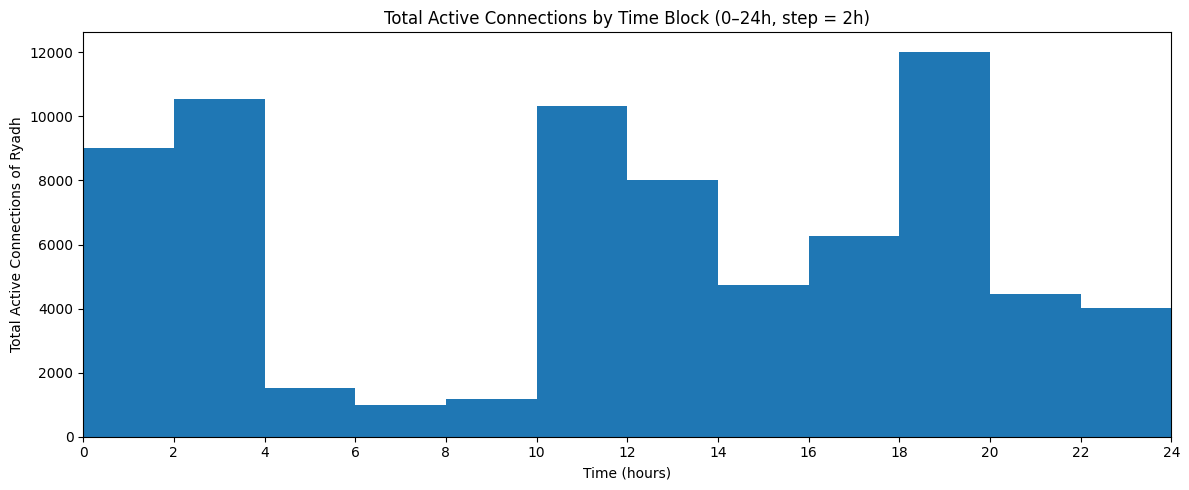

In [6]:
# ===== 1. Data normalization =====
df["ActiveConnections"] = df["ActiveConnections"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Total ActiveConnections per TimeBlock (1 → 12) =====
result = (
    df
    .groupby("TimeBlock")["ActiveConnections"]
    .sum()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_active_connections")
)

# ===== 3. Time block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))

plt.bar(
    x=result["x_left"],
    height=result["total_active_connections"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Total Active Connections of Ryadh")
plt.title("Total Active Connections by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()

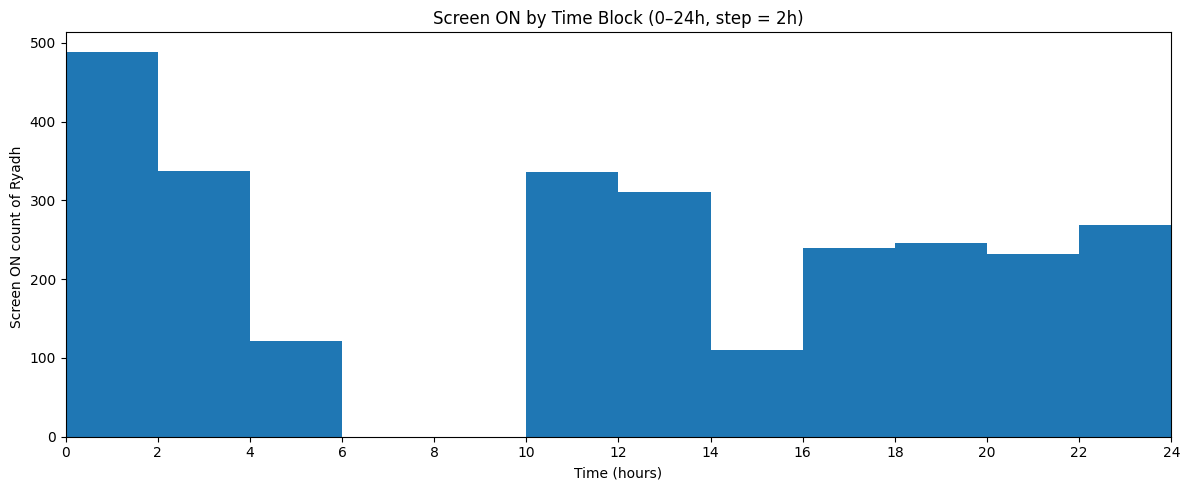

In [7]:
# ===== 1. Data normalization =====
df["DeviceScreenState"] = df["DeviceScreenState"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Create complete Time Blocks 1 → 12 =====
result = (
    df[df["DeviceScreenState"] == 1]
    .groupby("TimeBlock")
    .size()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_rows")
)

# ===== 3. Time Block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))

plt.bar(
    x=result["x_left"],
    height=result["total_rows"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 (DO NOT label 0–2) =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Screen ON count of Ryadh ")
plt.title("Screen ON by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()

In [8]:
df = pd.read_csv("data.csv")
print(df.columns)  

Index(['TimeBlock', 'AveragePackets', 'AveragePacketsperDevice',
       'AverageConnections', 'AverageConnectionsperDevice',
       'AverageThroughputperDevice', 'MaxThroughputperDevice',
       'ActiveDevicesIP', 'ConnectedDevicesMAC', 'AveragePacketSize',
       'ActiveConnections', 'RatioTIME_WAIT/ESTABLISHED', 'MaxTCPConnections',
       'MaxUDPConnections', 'TimeSinceLastTCPConnection',
       'TimeSinceLastUDPConnection', 'AverageTCPSessionDuration',
       'AverageUDPSessionDuration', 'TimeSinceLastPacket',
       'DeviceScreenState'],
      dtype='object')


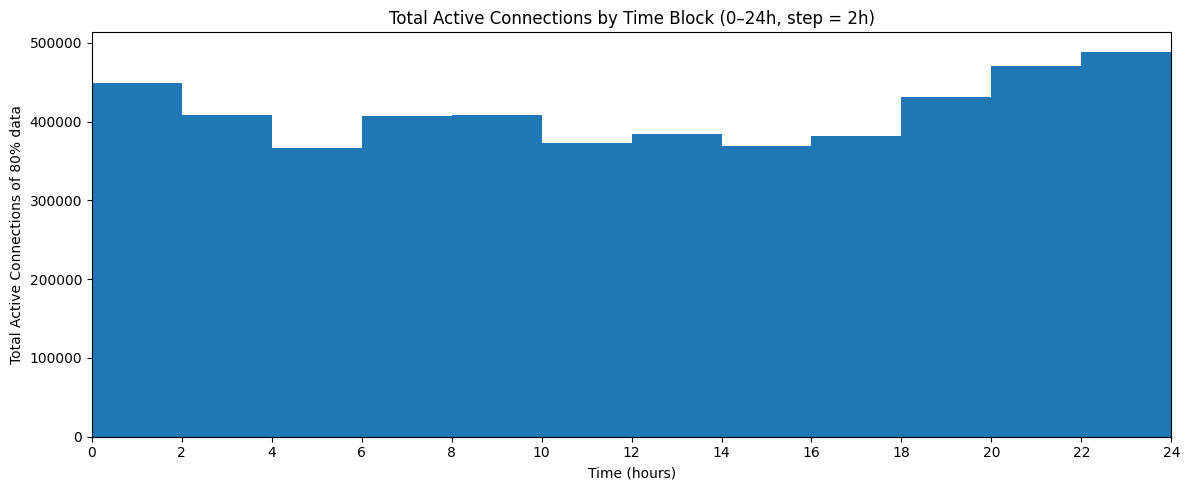

In [9]:
# ===== 1. Data normalization =====
df["ActiveConnections"] = df["ActiveConnections"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Total ActiveConnections per TimeBlock (1 → 12) =====
result = (
    df
    .groupby("TimeBlock")["ActiveConnections"]
    .sum()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_active_connections")
)

# ===== 3. Time block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))

plt.bar(
    x=result["x_left"],
    height=result["total_active_connections"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Total Active Connections of 80% data")
plt.title("Total Active Connections by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()

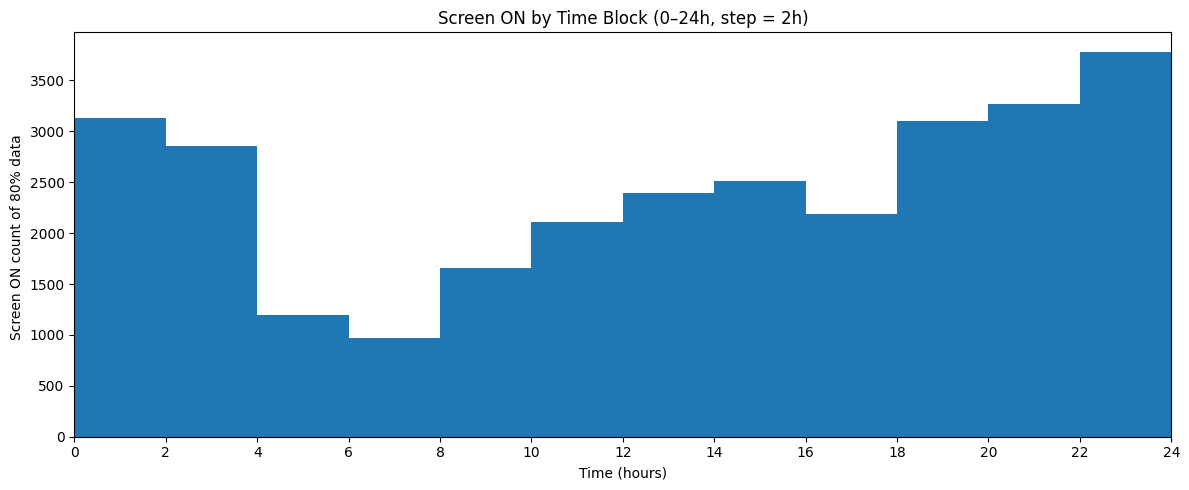

In [10]:
# ===== 1. Data normalization =====
df["DeviceScreenState"] = df["DeviceScreenState"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Create complete Time Blocks 1 → 12 =====
result = (
    df[df["DeviceScreenState"] == 1]
    .groupby("TimeBlock")
    .size()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_rows")
)

# ===== 3. Time Block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))

plt.bar(
    x=result["x_left"],
    height=result["total_rows"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 (DO NOT label 0–2) =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Screen ON count of 80% data ")
plt.title("Screen ON by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()

2. Modelling

In [11]:
from autogluon.tabular import TabularPredictor, TabularDataset
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load and clean data
data = TabularDataset("data.csv")
data.columns = data.columns.str.replace(r"[ ()]", "", regex=True)
data = data[data["ConnectedDevicesMAC"] != 0]

In [13]:
# Define target column
label = "DeviceScreenState"
data = TabularDataset(data)
display(data)
# Print raw class counts
display(data[label].value_counts())

,TimeBlock,AveragePackets,AveragePacketsperDevice,AverageConnections,AverageConnectionsperDevice,AverageThroughputperDevice,MaxThroughputperDevice,ActiveDevicesIP,ConnectedDevicesMAC,AveragePacketSize,ActiveConnections,RatioTIME_WAIT/ESTABLISHED,MaxTCPConnections,MaxUDPConnections,TimeSinceLastTCPConnection,TimeSinceLastUDPConnection,AverageTCPSessionDuration,AverageUDPSessionDuration,TimeSinceLastPacket,DeviceScreenState
0,10,993.533333,993.533333,1.633333,1.633333,9.216077e+05,9.216077e+05,1,1,30.920207,49,0.224490,0,0,0.0,0.0,0.000000,0.000000,0.0,1
1,10,1211.733333,1211.733333,1.400000,1.400000,1.142716e+06,1.142716e+06,1,1,31.434756,42,0.166667,0,0,0.0,0.0,0.000000,0.000000,0.0,1
2,10,1456.333333,1456.333333,1.366667,1.366667,1.380936e+06,1.380936e+06,1,1,31.607592,41,0.146341,0,0,0.0,0.0,0.000000,0.000000,0.0,1
3,10,1410.700000,1410.700000,1.233333,1.233333,1.376384e+06,1.376384e+06,1,1,32.522481,37,0.135135,0,0,0.0,0.0,0.000000,0.000000,0.0,1
4,10,1170.566667,1170.566667,0.933333,0.933333,1.140105e+06,1.140105e+06,1,1,32.465894,28,0.178571,18,10,0.0,0.0,45.000000,55.500000,15.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85682,5,151.366667,30.273333,4.766667,0.953333,9.853307e+03,4.926653e+04,5,2,10.849270,186,0.026882,0,0,15.0,15.0,45.000000,30.000000,15.0,0
85683,5,133.033333,22.172222,4.400000,0.733333,7.032094e+03,4.219257e+04,6,3,10.571929,195,0.087179,16,4,0.0,0.0,27915.000000,55.714286,15.0,0
85684,5,128.733333,21.455556,4.266667,0.711111,6.563561e+03,3.938137e+04,6,3,10.197143,200,0.080000,9,2,0.0,0.0,75.000000,37.500000,15.0,1
85685,5,118.000000,19.666667,3.900000,0.650000,5.841833e+03,3.505100e+04,6,3,9.901412,187,0.085561,1,0,0.0,15.0,111.818182,15.000000,15.0,1


DeviceScreenState
0    48698
1    29143
Name: count, dtype: int64

DeviceScreenState
0    0.625609
1    0.374391
Name: proportion, dtype: float64

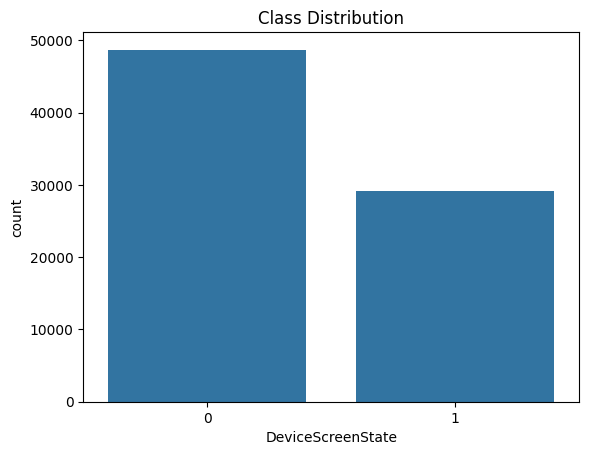

In [14]:
# Print class proportions
display(data[label].value_counts(normalize=True))

sns.countplot(x=label, data=data)
plt.title("Class Distribution")
plt.show()

2. Train Model

In [15]:
predictor = TabularPredictor(label=label, eval_metric="accuracy").fit(data, presets="high_quality")

No path specified. Models will be saved in: "AutogluonModels\ag-20251218_152956"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.6
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Memory Avail:       0.58 GB / 7.62 GB (7.6%)
Disk Space Avail:   18.98 GB / 163.04 GB (11.6%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.


Loaded data from: busson20.csv | Columns = 20 / 20 | Rows = 13050 -> 13050
C:\Users\ASUS ZENBOOK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Leaderboard (sorted by score_test):


,model,score_test,accuracy,recall,precision,f1,roc_auc,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1_FULL,0.908756,0.908756,0.791083,0.945592,0.861464,0.979226,NaN,accuracy,1.736235,NaN,40.931702,1.736235,NaN,40.931702,1,True,23
1,RandomForestGini_BAG_L1_FULL,0.902896,0.902896,0.779412,0.939505,0.852003,0.984532,NaN,accuracy,0.660404,4.212179,15.509117,0.660404,4.212179,15.509117,1,True,25
2,RandomForestGini_BAG_L1,0.902896,0.902896,0.779412,0.939505,0.852003,0.984532,0.962989,accuracy,1.081074,4.212179,15.509117,1.081074,4.212179,15.509117,1,True,3
3,RandomForestEntr_BAG_L1_FULL,0.899213,0.899213,0.765173,0.943038,0.844845,0.984484,NaN,accuracy,0.604369,4.443014,18.127880,0.604369,4.443014,18.127880,1,True,26
4,RandomForestEntr_BAG_L1,0.899213,0.899213,0.765173,0.943038,0.844845,0.984484,0.964325,accuracy,0.610833,4.443014,18.127880,0.610833,4.443014,18.127880,1,True,4
5,LightGBMXT_BAG_L2_FULL,0.896869,0.896869,0.760271,0.940786,0.840950,0.978362,NaN,accuracy,6.851029,NaN,367.322345,0.091524,NaN,1.488437,2,True,33
6,RandomForestEntr_BAG_L2_FULL,0.894358,0.894358,0.752568,0.941039,0.836316,0.967854,NaN,accuracy,7.170629,NaN,383.141041,0.411123,4.231010,17.307133,2,True,36
7,CatBoost_BAG_L2_FULL,0.894107,0.894107,0.754902,0.937663,0.836415,0.973890,NaN,accuracy,6.815686,NaN,368.560589,0.056181,NaN,2.726681,2,True,37
8,RandomForestGini_BAG_L2_FULL,0.893939,0.893939,0.753268,0.938900,0.835902,0.965374,NaN,accuracy,7.184823,NaN,387.251878,0.425317,4.395304,21.417970,2,True,35
9,ExtraTreesGini_BAG_L2_FULL,0.893772,0.893772,0.756069,0.935316,0.836195,0.967539,NaN,accuracy,7.286025,NaN,369.752823,0.526519,4.694736,3.918915,2,True,38


Computing feature importance via permutation shuffling for 19 features using 5000 rows with 5 shuffle sets...



Best model (highest recall, then accuracy): LightGBMXT_BAG_L1_FULL

Test set performance on valid rows only:
accuracy: 0.9087560689770634
balanced_accuracy: 0.8828164129133773
mcc: 0.8012670206076502
roc_auc: 0.9792259677733444
f1: 0.8614641586171835
precision: 0.9455915178571429
recall: 0.7910830999066293


	66.53s	= Expected runtime (13.31s per shuffle set)
	61.11s	= Actual runtime (Completed 5 of 5 shuffle sets)


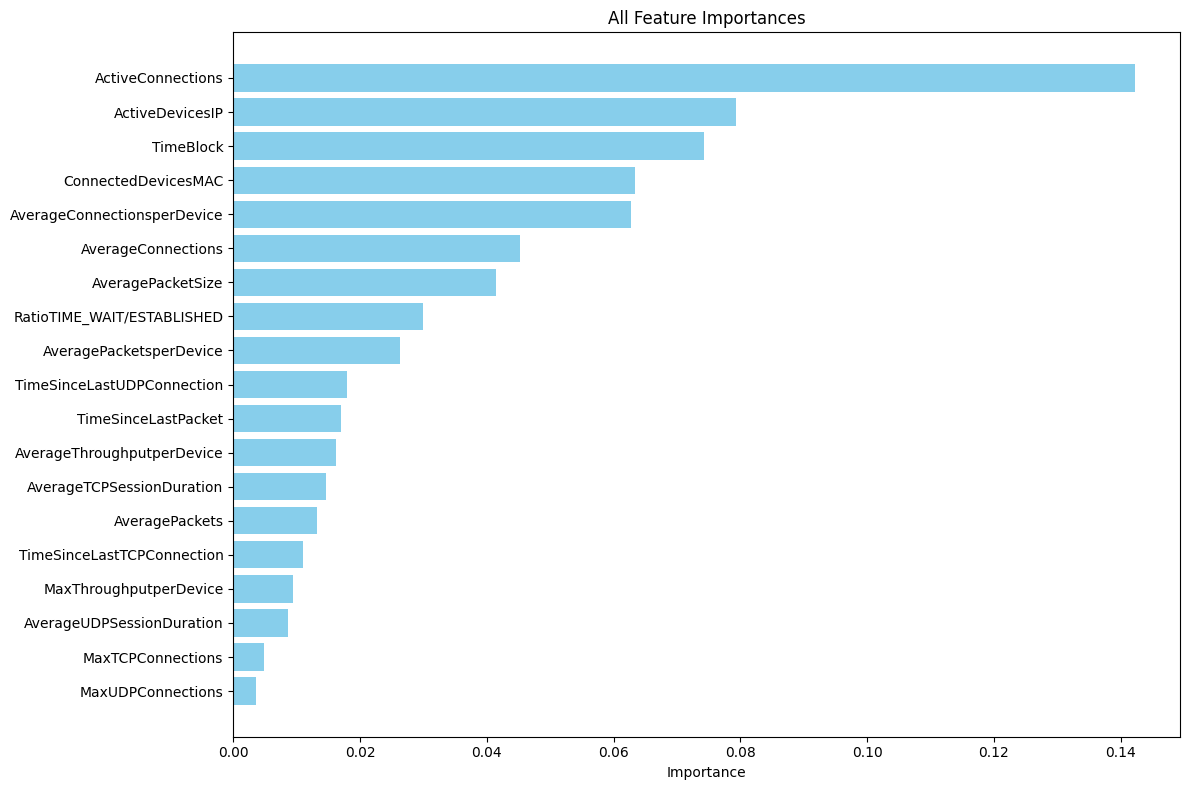

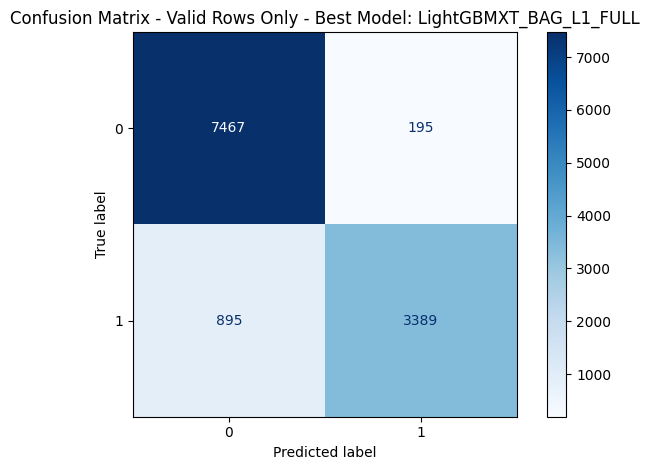

In [16]:
# Load and clean validation set
validation = TabularDataset("busson20.csv")
validation.columns = data.columns.str.replace(r"[ ()]", "", regex=True)

# Separate invalid and valid rows
invalid_rows = validation[validation["ConnectedDevicesMAC"] == 0].copy()
valid_rows = validation[validation["ConnectedDevicesMAC"] != 0].copy()

# Run leaderboard only on valid rows
leaderboard = predictor.leaderboard(valid_rows, extra_metrics=["accuracy", "recall", "precision", "f1", "roc_auc"], silent=True)
print("\nLeaderboard (sorted by score_test):")
display(leaderboard.sort_values(by="score_test", ascending=False))

# Get the highest score_test (assumed to be recall)
max_score_test = leaderboard["score_test"].max()
top_models = leaderboard[leaderboard["score_test"] == max_score_test]

# Select best model based on recall, then accuracy
best_model = None
best_accuracy = -float("inf")
best_model_results = None

if len(top_models) == 1:
    best_model = top_models.iloc[0]["model"]
    best_model_results = predictor.evaluate(valid_rows, model=best_model, silent=True)
else:
    for _, row in top_models.iterrows():
        model = row["model"]
        accuracy = row["accuracy"]
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_model_results = predictor.evaluate(valid_rows, model=best_model, silent=True)

# Show best model results
print(f"\nBest model (highest recall, then accuracy): {best_model}")
print("\nTest set performance on valid rows only:")
for metric, score in best_model_results.items():
    print(f"{metric}: {score}")

# Feature importance
importance_df = predictor.feature_importance(data, model=best_model)
importance_df_sorted = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df_sorted.index[::-1], importance_df_sorted["importance"].values[::-1], color='skyblue')
plt.xlabel("Importance")
plt.title("All Feature Importances")
plt.tight_layout()
plt.show()

# Predict on valid rows
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_valid = valid_rows["DeviceScreenState"]
y_pred_valid = predictor.predict(valid_rows, model=best_model)

# Predict on invalid rows (manually assign label 0)
invalid_rows["Predicted"] = 0
valid_rows["Predicted"] = y_pred_valid

# Confusion matrix only for valid data
cm = confusion_matrix(y_true_valid, y_pred_valid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Valid Rows Only - Best Model: {best_model}")
plt.tight_layout()
plt.show()

# OPTIONAL: Combine if you need all predictions
full_results = pd.concat([valid_rows, invalid_rows], ignore_index=True)

In [17]:
# Step 2: Identify features to remove (negative importance)
features_to_remove = importance_df[importance_df["importance"] <= 0].index.tolist()
print("\nFeatures with negative importance to remove:", features_to_remove)

# Step 3: Remove features from training and validation data
data_reduced = data.drop(columns=features_to_remove)
display(data_reduced)


Features with negative importance to remove: []


,TimeBlock,AveragePackets,AveragePacketsperDevice,AverageConnections,AverageConnectionsperDevice,AverageThroughputperDevice,MaxThroughputperDevice,ActiveDevicesIP,ConnectedDevicesMAC,AveragePacketSize,ActiveConnections,RatioTIME_WAIT/ESTABLISHED,MaxTCPConnections,MaxUDPConnections,TimeSinceLastTCPConnection,TimeSinceLastUDPConnection,AverageTCPSessionDuration,AverageUDPSessionDuration,TimeSinceLastPacket,DeviceScreenState
0,10,993.533333,993.533333,1.633333,1.633333,9.216077e+05,9.216077e+05,1,1,30.920207,49,0.224490,0,0,0.0,0.0,0.000000,0.000000,0.0,1
1,10,1211.733333,1211.733333,1.400000,1.400000,1.142716e+06,1.142716e+06,1,1,31.434756,42,0.166667,0,0,0.0,0.0,0.000000,0.000000,0.0,1
2,10,1456.333333,1456.333333,1.366667,1.366667,1.380936e+06,1.380936e+06,1,1,31.607592,41,0.146341,0,0,0.0,0.0,0.000000,0.000000,0.0,1
3,10,1410.700000,1410.700000,1.233333,1.233333,1.376384e+06,1.376384e+06,1,1,32.522481,37,0.135135,0,0,0.0,0.0,0.000000,0.000000,0.0,1
4,10,1170.566667,1170.566667,0.933333,0.933333,1.140105e+06,1.140105e+06,1,1,32.465894,28,0.178571,18,10,0.0,0.0,45.000000,55.500000,15.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85682,5,151.366667,30.273333,4.766667,0.953333,9.853307e+03,4.926653e+04,5,2,10.849270,186,0.026882,0,0,15.0,15.0,45.000000,30.000000,15.0,0
85683,5,133.033333,22.172222,4.400000,0.733333,7.032094e+03,4.219257e+04,6,3,10.571929,195,0.087179,16,4,0.0,0.0,27915.000000,55.714286,15.0,0
85684,5,128.733333,21.455556,4.266667,0.711111,6.563561e+03,3.938137e+04,6,3,10.197143,200,0.080000,9,2,0.0,0.0,75.000000,37.500000,15.0,1
85685,5,118.000000,19.666667,3.900000,0.650000,5.841833e+03,3.505100e+04,6,3,9.901412,187,0.085561,1,0,0.0,15.0,111.818182,15.000000,15.0,1


In [18]:
# Step 4: Retrain model with reduced feature set
predictor_reduced = TabularPredictor(label=label, eval_metric="accuracy").fit(data_reduced, presets="good")

No path specified. Models will be saved in: "AutogluonModels\ag-20251219_111040"
Preset alias specified: 'good' maps to 'good_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.6
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Memory Avail:       1.19 GB / 7.62 GB (15.6%)
Disk Space Avail:   13.65 GB / 163.04 GB (8.4%)
Presets specified: ['good']
Using hyperparameters preset: hyperparameters='light'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid 

C:\Users\ASUS ZENBOOK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Leaderboard after removing features (sorted by score_test):


,model,score_test,accuracy,recall,precision,f1,roc_auc,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1_FULL,0.913276,0.913276,0.802521,0.947630,0.869060,0.982851,NaN,accuracy,2.350676,NaN,15.693054,2.350676,NaN,15.693054,1,True,21
1,RandomForestGini_BAG_L1_FULL,0.896116,0.896116,0.759804,0.938852,0.839892,0.984314,NaN,accuracy,0.556959,3.656657,15.127333,0.556959,3.656657,15.127333,1,True,23
2,RandomForestGini_BAG_L1,0.896116,0.896116,0.759804,0.938852,0.839892,0.984314,0.951170,accuracy,1.610556,3.656657,15.127333,1.610556,3.656657,15.127333,1,True,3
3,RandomForestEntr_BAG_L1_FULL,0.894525,0.894525,0.751634,0.942623,0.836364,0.984422,NaN,accuracy,0.390333,3.767926,15.576647,0.390333,3.767926,15.576647,1,True,24
4,RandomForestEntr_BAG_L1,0.894525,0.894525,0.751634,0.942623,0.836364,0.984422,0.950771,accuracy,0.589511,3.767926,15.576647,0.589511,3.767926,15.576647,1,True,4
5,XGBoost_BAG_L1_FULL,0.892349,0.892349,0.756069,0.930747,0.834364,0.972364,NaN,accuracy,0.579995,NaN,2.478384,0.579995,NaN,2.478384,1,True,29
6,RandomForestEntr_BAG_L2_FULL,0.891679,0.891679,0.748599,0.936624,0.832122,0.966586,NaN,accuracy,6.682291,NaN,299.282827,0.416719,4.273270,20.679265,2,True,34
7,LightGBMXT_BAG_L2_FULL,0.891010,0.891010,0.745798,0.937500,0.830733,0.973328,NaN,accuracy,6.382512,NaN,283.876815,0.116940,NaN,5.273252,2,True,31
8,ExtraTreesEntr_BAG_L2_FULL,0.890089,0.890089,0.752334,0.927482,0.830777,0.970162,NaN,accuracy,6.845502,NaN,281.950681,0.579930,3.945698,3.347119,2,True,37
9,ExtraTreesGini_BAG_L2_FULL,0.888666,0.888666,0.748133,0.927373,0.828165,0.969980,NaN,accuracy,6.698802,NaN,282.217261,0.433229,4.418445,3.613698,2,True,36


Computing feature importance via permutation shuffling for 19 features using 5000 rows with 5 shuffle sets...



Best model (recall): LightGBMXT_BAG_L1_FULL

Test set performance on valid rows only:
accuracy: 0.9132764105139796
balanced_accuracy: 0.88886165272687
mcc: 0.811106386604069
roc_auc: 0.9828506013037773
f1: 0.8690596562184024
precision: 0.9476295479603087
recall: 0.8025210084033614


	81.06s	= Expected runtime (16.21s per shuffle set)
	33.39s	= Actual runtime (Completed 5 of 5 shuffle sets)


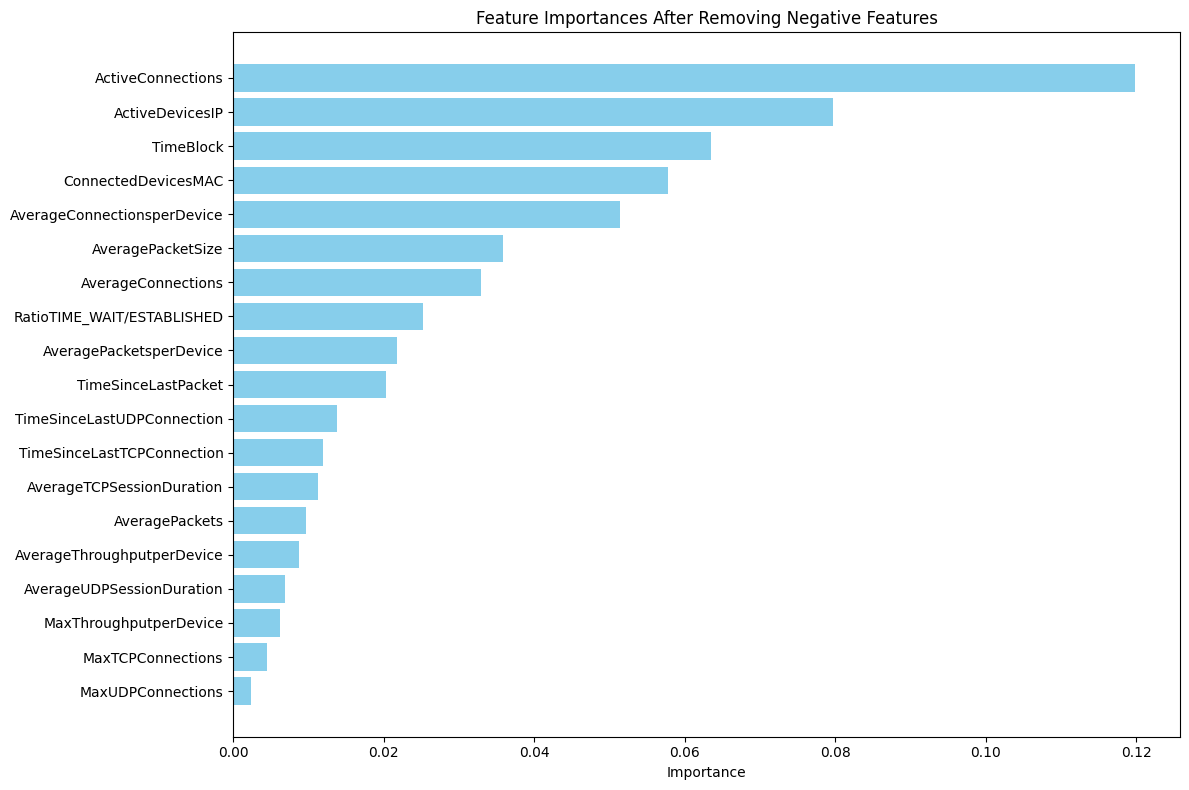

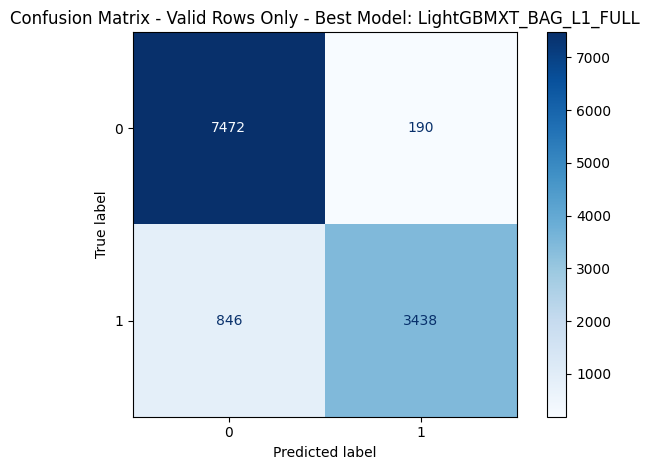

In [19]:
# Clean validation column names
validation.columns = validation.columns.str.replace(r"[ ()]", "", regex=True)

# Separate invalid and valid validation rows
invalid_rows_reduced = validation[validation["ConnectedDevicesMAC"] == 0].copy()
valid_rows_reduced = validation[validation["ConnectedDevicesMAC"] != 0].copy()

# Step 5: Evaluate reduced model only on valid rows
leaderboard_reduced = predictor_reduced.leaderboard(valid_rows_reduced, extra_metrics=["accuracy", "recall", "precision", "f1", "roc_auc"], silent=True)
print("\nLeaderboard after removing features (sorted by score_test):")
display(leaderboard_reduced.sort_values(by="score_test", ascending=False))

# Get best model by recall (then accuracy if needed)
max_score_test = leaderboard_reduced["score_test"].max()
top_models_reduced = leaderboard_reduced[leaderboard_reduced["score_test"] == max_score_test]

best_model_reduced = None
best_accuracy = -float("inf")
best_model_results_reduced = None

if len(top_models_reduced) == 1:
    best_model_reduced = top_models_reduced.iloc[0]["model"]
    best_model_results_reduced = predictor_reduced.evaluate(valid_rows_reduced, model=best_model_reduced, silent=True)
else:
    for _, row in top_models_reduced.iterrows():
        model = row["model"]
        accuracy = row["accuracy"]

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model_reduced = model
            best_model_results_reduced = predictor_reduced.evaluate(valid_rows_reduced, model=best_model_reduced, silent=True)

print(f"\nBest model (recall): {best_model_reduced}")
print("\nTest set performance on valid rows only:")
for metric, score in best_model_results_reduced.items():
    print(f"{metric}: {score}")

# Step 6: Plot new feature importances
importance_df_reduced = predictor_reduced.feature_importance(data_reduced, model=best_model_reduced)
importance_df_sorted_reduced = importance_df_reduced.sort_values("importance", ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df_sorted_reduced.index[::-1], importance_df_sorted_reduced["importance"].values[::-1], color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importances After Removing Negative Features")
plt.tight_layout()
plt.show()

# Confusion matrix (valid rows only)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_valid_reduced = valid_rows_reduced["DeviceScreenState"]
y_pred_valid_reduced = predictor_reduced.predict(valid_rows_reduced, model=best_model_reduced)

cm = confusion_matrix(y_true_valid_reduced, y_pred_valid_reduced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Valid Rows Only - Best Model: {best_model_reduced}")
plt.tight_layout()
plt.show()

# OPTIONAL: Predict 0 for invalid rows and combine (if needed later)
invalid_rows_reduced["Predicted"] = 0
valid_rows_reduced["Predicted"] = y_pred_valid_reduced
full_results_reduced = pd.concat([valid_rows_reduced, invalid_rows_reduced], ignore_index=True)

Test

In [20]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

Loaded data from: busson20.csv | Columns = 20 / 20 | Rows = 13050 -> 13050


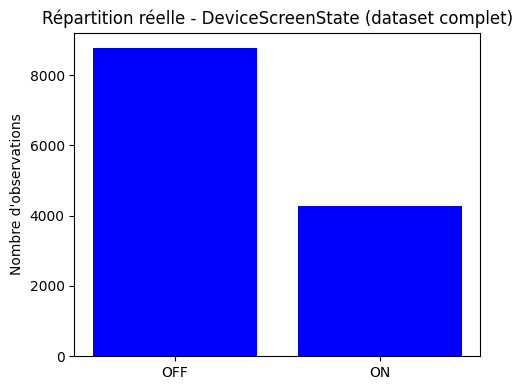

In [21]:
data = TabularDataset("busson20.csv") 
data.columns = data.columns.str.replace(r"[ ()]", "", regex=True)
original_labels = data["DeviceScreenState"].copy()  # Sauvegarde des vraies valeurs
original_counts = data["DeviceScreenState"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(original_counts.index.map({0: "OFF", 1: "ON"}), original_counts.values, color=["Blue", "Blue"])
plt.title("Répartition réelle - DeviceScreenState (dataset complet)")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

In [22]:
leaderboard_reduced = predictor_reduced.leaderboard(
    valid_rows_reduced,
    extra_metrics=["recall", "accuracy", "precision", "f1", "roc_auc"],
    silent=True)

C:\Users\ASUS ZENBOOK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
# priorize recall (class = 1)
max_recall = leaderboard_reduced["recall"].max()
top_models = leaderboard_reduced[leaderboard_reduced["recall"] == max_recall]

# If there are multiple models, break the tie using accuracy.
best_row = top_models.sort_values("accuracy", ascending=False).iloc[0]
best_model_reduced = best_row["model"]

print("✅ Selected best model after retraining:")
print(f"Model    : {best_model_reduced}")
print(f"Recall   : {best_row['recall']:.4f}")
print(f"Accuracy : {best_row['accuracy']:.4f}")

✅ Selected best model after retraining:
Model    : LightGBMXT_BAG_L1_FULL
Recall   : 0.8025
Accuracy : 0.9133


In [24]:
predictions = predictor_reduced.predict(
    valid_rows_reduced,
    model=best_model_reduced)

In [25]:
print (predictions)

0        0
1        0
2        0
3        0
4        0
        ..
13045    0
13046    0
13047    0
13048    0
13049    0
Name: DeviceScreenState, Length: 11946, dtype: int64


Because: valid_rows_reduced = validation[validation["ConnectedDevicesMAC"] != 0].copy()

In [26]:
print(predictions.shape)

(11946,)


In [27]:
data["Predicted_Label"] = predictions

In [28]:
data.loc[data["ConnectedDevicesMAC"] == 0, "Predicted_Label"] = 0

In [29]:
data["State"] = 0

In [30]:
# === Propagation initiale ===
N_TBO = 5 # Nombre de lignes à propager après un Predicted_Label = 1
for i in range(len(data)):
    if data.loc[i, "Predicted_Label"] == 1:
        end = min(i + N_TBO, len(data))
        data.loc[i:end, "State"] = 1

# === Extinction et rallumage ===
N_off = 5 # Nombre de lignes à éteindre après un 0
N_on = 5   # Nombre de lignes à rallumer si un 1 est détecté juste après extinction

i = 0
while i < len(data):
    if data.loc[i, "State"] == 0:
        # Extinction : mettre les N_off lignes suivantes à 0
        for j in range(1, N_off + 1):
            if i + j < len(data):
                data.loc[i + j, "State"] = 0

        # Rallumage : si ligne après extinction est 1 rallumer N_on lignes
        if i + N_off < len(data) :
            for k in range(1, N_on + 1):
                if i + N_off + k < len(data):
                    data.loc[i + N_off + k, "State"] = 1

        i += N_off + 1  # avancer après extinction et test de rallumage
    else:
        i += 1

In [31]:
y_true = original_labels
y_pred = data["State"]
y_pred2 = data["Predicted_Label"]

In [32]:
print (y_true  )

0        0
1        0
2        0
3        0
4        0
        ..
13045    0
13046    0
13047    0
13048    0
13049    0
Name: DeviceScreenState, Length: 13050, dtype: int64


In [33]:
print (y_pred  )

0        0
1        0
2        0
3        0
4        0
        ..
13045    0
13046    0
13047    0
13048    1
13049    1
Name: State, Length: 13050, dtype: int64


In [34]:
print (y_pred2  )

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
13045    0.0
13046    0.0
13047    0.0
13048    0.0
13049    0.0
Name: Predicted_Label, Length: 13050, dtype: float64


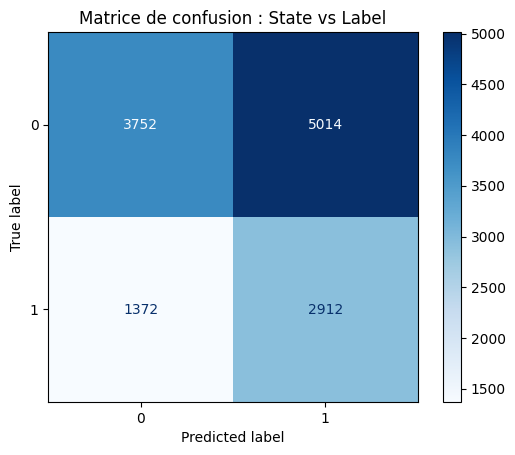

✅ Recall (classe 1): 0.6797


In [35]:
from sklearn.metrics import recall_score
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion : State vs Label")
plt.show()
# Print recall score
recall = recall_score(y_true, y_pred)
print(f"✅ Recall (classe 1): {recall:.4f}")

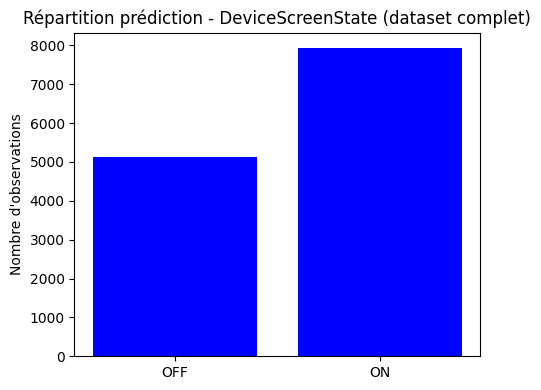

In [36]:
original_counts = data["State"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(original_counts.index.map({0: "OFF", 1: "ON"}), original_counts.values, color=["Blue", "Blue"])
plt.title("Répartition prédiction - DeviceScreenState (dataset complet)")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

In [37]:

def print_state_distribution(title, subset):
    counts = subset["State"].value_counts(normalize=True).sort_index()
    print(f"\n🔹 {title}")
    print(f" - State = OFF : {counts.get(0, 0)*100:.2f}%")
    print(f" - State = ON : {counts.get(1, 0)*100:.2f}%")

# Global
print_state_distribution("Distribution globale de State", data)

# ConnectedDevicesMAC != 0
subset_active = data[data["ConnectedDevicesMAC"] != 0]
print_state_distribution("State avec des stations connecté", subset_active)

# ConnectedDevicesMAC == 0
subset_inactive = data[data["ConnectedDevicesMAC"] == 0]
print_state_distribution("State sans stations connecté", subset_inactive)


🔹 Distribution globale de State
 - State = OFF : 39.26%
 - State = ON : 60.74%

🔹 State avec des stations connecté
 - State = OFF : 37.85%
 - State = ON : 62.15%

🔹 State sans stations connecté
 - State = OFF : 54.53%
 - State = ON : 45.47%


In [38]:
print(data.columns)

Index(['TimeBlock', 'AveragePackets', 'AveragePacketsperDevice',
       'AverageConnections', 'AverageConnectionsperDevice',
       'AverageThroughputperDevice', 'MaxThroughputperDevice',
       'ActiveDevicesIP', 'ConnectedDevicesMAC', 'AveragePacketSize',
       'ActiveConnections', 'RatioTIME_WAIT/ESTABLISHED', 'MaxTCPConnections',
       'MaxUDPConnections', 'TimeSinceLastTCPConnection',
       'TimeSinceLastUDPConnection', 'AverageTCPSessionDuration',
       'AverageUDPSessionDuration', 'TimeSinceLastPacket', 'DeviceScreenState',
       'Predicted_Label', 'State'],
      dtype='object')


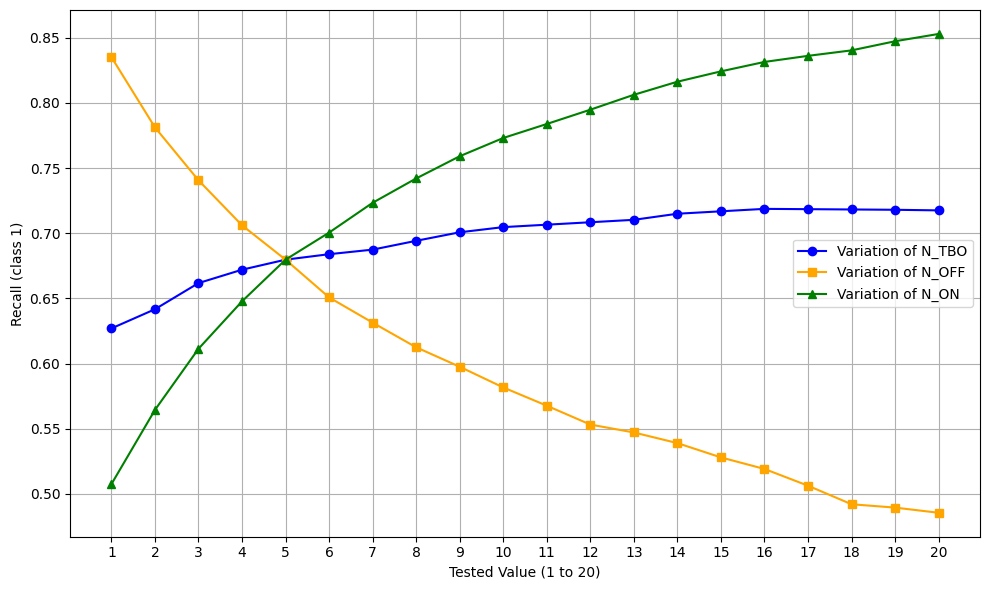

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay

def run_propagation(data, N, N_off, N_on):
    df = data.copy()
    
    # === Initial propagation ===
    for i in range(len(df)):
        if df.loc[i, "Predicted_Label"] == 1:
            end = min(i + N, len(df))
            df.loc[i:end, "State"] = 1

    # === Shutdown and restart ===
    i = 0
    while i < len(df):
        if df.loc[i, "State"] == 0:
            for j in range(1, N_off + 1):
                if i + j < len(df):
                    df.loc[i + j, "State"] = 0

            if i + N_off < len(df):
                for k in range(1, N_on + 1):
                    if i + N_off + k < len(df):
                        df.loc[i + N_off + k, "State"] = 1
            i += N_off + 1
        else:
            i += 1

    return recall_score(original_labels, df["State"])

# === Tests for N, N_off, N_on ===
x_range = list(range(1, 21))
recalls_N = []
recalls_N_off = []
recalls_N_on = []

for val in x_range:
    # Test variation of N (fixed N_off and N_on)
    data["State"] = 0  # Reset
    recalls_N.append(run_propagation(data, N=val, N_off=5, N_on=5))

    # Test variation of N_off
    data["State"] = 0
    recalls_N_off.append(run_propagation(data, N=5, N_off=val, N_on=5))

    # Test variation of N_on
    data["State"] = 0
    recalls_N_on.append(run_propagation(data, N=5, N_off=5, N_on=val))

# === Plotting the graph ===
plt.figure(figsize=(10, 6))
plt.xticks(x_range)
plt.plot(x_range, recalls_N, label="Variation of N_TBO",color="blue", marker='o')
plt.plot(x_range, recalls_N_off, label="Variation of N_OFF",color="orange", marker='s')
plt.plot(x_range, recalls_N_on, label="Variation of N_ON",color="green", marker='^')
#plt.title("Recall Evolution According to Propagation Parameters")
plt.xlabel("Tested Value (1 to 20)")
plt.ylabel("Recall (class 1)") 
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

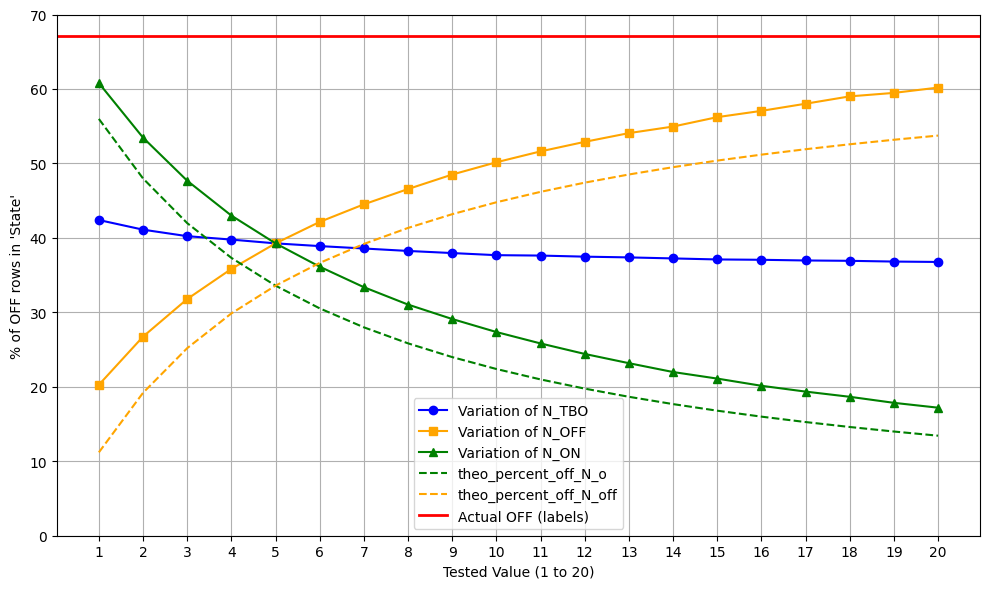

In [47]:
# === New version of the function: returns % OFF instead of recall ===
def run_propagation_percent_off(data, N, N_off, N_on):
    df = data.copy()

    for i in range(len(df)):
        if df.loc[i, "Predicted_Label"] == 1:
            end = min(i + N, len(df))
            df.loc[i:end, "State"] = 1

    i = 0
    while i < len(df):
        if df.loc[i, "State"] == 0:
            for j in range(1, N_off + 1):
                if i + j < len(df):
                    df.loc[i + j, "State"] = 0
            if i + N_off < len(df):
                for k in range(1, N_on + 1):
                    if i + N_off + k < len(df):
                        df.loc[i + N_off + k, "State"] = 1
            i += N_off + 1
        else:
            i += 1

    counts = df["State"].value_counts(normalize=True) * 100  # In percentage
    return counts.get(0, 0)  # % of OFF (State == 0)

true_off_percent = original_labels.value_counts(normalize=True).get(0, 0) * 100

# === Calculation for each case ===
percent_off_N = []
percent_off_N_off = []
percent_off_N_on = []
N_off_fixed = 5  
theo_percent_off_N_on = [
    (N_off_fixed / (N_off_fixed + N_on)) *true_off_percent
    for N_on in x_range
]
N_on_fixed = 5  
theo_percent_off_N_off = [
    (N_off / (N_off + N_on_fixed)) * true_off_percent
    for N_off in x_range
]

for val in x_range:
    data["State"] = 0
    percent_off_N.append(run_propagation_percent_off(data, N=val, N_off=5, N_on=5))

    data["State"] = 0
    percent_off_N_off.append(run_propagation_percent_off(data, N=5, N_off=val, N_on=5))

    data["State"] = 0
    percent_off_N_on.append(run_propagation_percent_off(data, N=5, N_off=5, N_on=val))

# === Plotting the graph ===
plt.figure(figsize=(10, 6))
plt.plot(x_range, percent_off_N, label="Variation of N_TBO",color="blue", marker='o')
plt.plot(x_range, percent_off_N_off, label="Variation of N_OFF",color="orange", marker='s')
plt.plot(x_range, percent_off_N_on, label="Variation of N_ON", color="green", marker='^')
plt.plot(x_range, theo_percent_off_N_on, label="theo_percent_off_N_o",color="green",  linestyle='dashed')
plt.plot(x_range, theo_percent_off_N_off, label="theo_percent_off_N_off", color="orange",  linestyle='dashed')
# Horizontal line = actual % OFF
plt.axhline(y=true_off_percent, color="red", linewidth=2, label="Actual OFF (labels)")

plt.xticks(x_range)
#plt.title("Evolution of % OFF (State == 0) According to Parameters")
plt.xlabel("Tested Value (1 to 20)")
plt.ylabel("% of OFF rows in 'State'")
plt.ylim(0, 70)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

dashed

In [46]:
# === New version of the function: returns % OFF instead of recall ===
# percent_theo_off_N_on.append(run_propagation_percent_off(data, N=10, N_off=5, N_on=val))
def run_propagation_percent_off(data, N, N_off, N_on):
    df = data.copy()

    for i in range(len(df)):
        if df.loc[i, "Predicted_Label"] == 1:
            end = min(i + N, len(df))
            df.loc[i:end, "State"] = 1

    i = 0
    while i < len(df):
        if df.loc[i, "State"] == 0:
            for j in range(1, N_off + 1):
                if i + j < len(df):
                    df.loc[i + j, "State"] = 0
            if i + N_off < len(df):
                for k in range(1, N_on + 1):
                    if i + N_off + k < len(df):
                        df.loc[i + N_off + k, "State"] = 1
            i += N_off + 1
        else:
            i += 1

    counts = df["State"].value_counts(normalize=True) * 100  # In percentage
    return counts.get(0, 0)  # % of OFF (State == 0)

true_off_percent = original_labels.value_counts(normalize=True).get(0, 0) * 100

# === Calculation for each case ===
percent_off_N = []
percent_off_N_off = []
percent_off_N_on = []
percent_theo_off_N_on = []
for val in x_range:
    data["State"] = 0
    percent_off_N.append(run_propagation_percent_off(data, N=val, N_off=5, N_on=5))

    data["State"] = 0
    percent_off_N_off.append(run_propagation_percent_off(data, N=5, N_off=val, N_on=5))
    
    data["State"] = 0
    percent_off_N_on.append(run_propagation_percent_off(data, N=5, N_off=5, N_on=val))
    data["State"] = 0
    percent_theo_off_N_on.append(run_propagation_percent_off(data, N=10, N_off=5, N_on=val))
# === Plotting the graph ===
plt.figure(figsize=(10, 6))
plt.plot(x_range, percent_off_N, label="Variation of N_TBO", color="blue", marker='o')
plt.plot(x_range, percent_off_N_off, label="Variation of N_OFF", color="blue", marker='s')
plt.plot(x_range, percent_theo_off_N_on, label="Variation theo of N_On",color="blue", marker='*')
plt.plot(x_range, percent_off_N_on, label="Variation of N_ON", color="blue", marker='^')
# Horizontal line = actual % OFF
plt.axhline(y=true_off_percent, color="red", linewidth=2, label="Actual OFF (labels)")

plt.xticks(x_range)
#plt.title("Evolution of % OFF (State == 0) According to Parameters")
plt.xlabel("Tested Value (1 to 20)")
plt.ylabel("% of OFF rows in 'State'")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (1770369792.py, line 48)